In [1]:
from tqdm import tqdm
tqdm.pandas()
from glob import glob

import json
import csv
import numpy as np
import numpy.random as rand
import pandas as pd
from collections import Counter

import rdflib
from rdflib import Graph
from data.data import CollectionAccessor, ImageHandler, EmbeddingSpaceAccessor

from search import Search, Randomiser, Equaliser, GraphSearcher, EmbeddingSearcher, TextEmbeddingSearcher
from moon import MOON, Moon

import requests as rq
import matplotlib.pyplot as plt

In [2]:
# from app import init_DMG, init_MKG, order_collection

# def lifespan():
#     global DMG
#     global DMG_searcher
#     global DMG_concept_search
#     DMG, DMG_searcher, DMG_concept_search = init_DMG()
# lifespan()

https://backend.not247.online/DMG_2025-05-13/search/order?skip=24820&limit=50&reverse=false&object_ids=1980-0014,3338&model_ids=KGSearcher0,SemanticSearcher2,VisualSearcher3


https://backend.not247.online/DMG_2025-05-13/search/sample?k=9&object_ids=1980-0014,3338&model_ids=KGSearcher0,SemanticSearcher2,VisualSearcher3

1980-0014 has a index of 24822 at /sample  
1980-0014 has a index of 24823 at /order

In [3]:
prefix = "http://0.0.0.0:8080/DMG_2025-06-06/"

params = dict(object_ids_index_of="1980-0014,3338", object_ids="1976-0043,2009-0011_03-10",
    k=24781, lat=51.05, long=3.71, model_ids="KGSearcher0,SemanticSearcher2,VisualSearcher3",
    filter_text="", skip=None, limit=None, reverse="false")

In [5]:
search_res = rq.get(prefix+"search", params=params).json()
search_res = pd.Series(search_res)

order_res = rq.get(prefix+"search/order", params=params).json()
order_res = pd.DataFrame.from_records(order_res).set_index("inventory_number")

indexes = rq.get(prefix+"search/order/indexof", params=params).json()
indexes = pd.Series(indexes)

default_res = rq.get(prefix+"default/order", params=params).json()
default_res = pd.DataFrame.from_records(default_res).set_index("inventory_number")

In [6]:
order_res.shape

(24781, 11)

In [7]:
sample_res = rq.get(prefix+"search/sample", params=params).json()["sampled_records"]
sample_res = pd.DataFrame.from_records(sample_res).set_index("inventory_number")

In [8]:
pairs = pd.concat([order_res.sort_index().order_index, 
                   sample_res.sort_index().order_index,
                   default_res.sort_index().order_index], axis=1)
pairs.columns = ["i1", "i2", "i3"]

pairs[pairs.i1 != pairs.i2].sort_values(by="i1")

,i1,i2,i3
inventory_number,,,


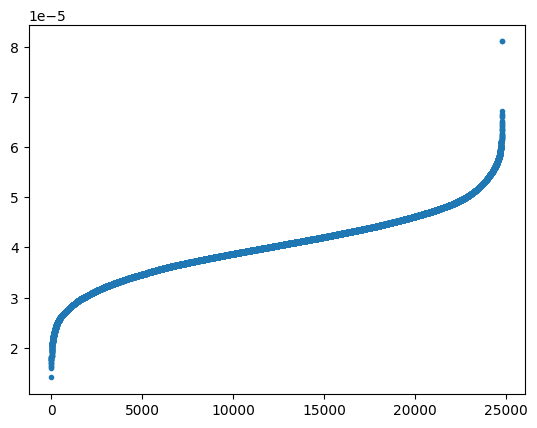

In [16]:
import matplotlib.pyplot as plt


plt.plot(search_res.sort_values().to_list(), ".")

In [ ]:
default_res.order_index

In [ ]:
search_res.loc[['1987-0022', '1984-0002_1', '2010-0066_DOCUMENTATIE',
       '2010-0079_DOCUMENTATIE', '2009-0011_03-10', '1976-0043']]

In [ ]:
for obj_num in sorted((set(sample_res.index) & set(order_res.index)):
    print(obj_num, order_res.loc[obj_num].order_index)
    print(obj_num, sample_res.loc[obj_num].order_index)
    print()

In [ ]:
order_res.loc["2009-0011_03-10"]

In [ ]:
len(search_res)

In [ ]:
# indexes = rq.get(prefix+"search/order/indexof", params=params).json()
# indexes = pd.Series(indexes)

params | dict(object_ids_index_of="2009-0011_03-10")

---

In [ ]:
sample = rq.get(prefix+"search/sample", params=params).json()
orig_recs = pd.DataFrame.from_records(sample["original_records"]).set_index("inventory_number")
sample = pd.DataFrame.from_records(sample["sampled_records"]).set_index("inventory_number")

In [ ]:
sample.order_index

In [ ]:
order_res.loc[sample.index].order_index

In [ ]:
request_ids = ",".join(sample.index)
print(request_ids)
params["object_ids_index_of"] = request_ids
indexes = rq.get(prefix+"search/order/indexof", 
                 params=params).json()
indexes = pd.Series(indexes)

indexes

In [ ]:
order_res.loc[sample.index].order_index

In [ ]:
search_res.argsort().loc[sample.index]

---

## fix `/search/order/filter`

In [ ]:
params = dict(object_ids="1980-0307_2-2,1995-0035",
    k=9, lat=51.05, long=3.71, model_ids="KGSearcher0,SemanticSearcher2,VisualSearcher3",
    filter_text="199", skip=0, limit=22, reverse="false")

filter_res = rq.get(prefix+"search/order/filter", params=params).json()
filter_res = pd.DataFrame.from_records(filter_res).set_index("inventory_number")


filter_res_rev = rq.get(prefix+"search/order/filter", params=params|dict(reverse="true")).json()
filter_res_rev = pd.DataFrame.from_records(filter_res_rev).set_index("inventory_number")


In [ ]:
filter_res.order_index.shape

In [ ]:
filter_res_rev.order_index.shape

---

### `/object-details`

In [ ]:
detail = rq.get(prefix+"object-details", params=dict(object_ids="2022-0025_3-3")).json()

detail

In [ ]:
params = dict(object_ids="1980-0307_2-2",
    k=9, lat=51.05, long=3.71, model_ids="KGSearcher0,SemanticSearcher2,VisualSearcher3",
    filter_text="2022-0025_3-3", skip=0, limit=22, reverse="true")

rq.get(prefix+"search/order/filter",
       params=params).json()
